In [ ]:
!pip install torchsummary
!pip install torchview

In [ ]:
# import numpy for math calculations
import numpy as np

# import pandas for data (csv) manipulation
import pandas as pd

# import gc to collect garbage
import gc

# import matplotlib for plotting
import matplotlib.pyplot as plt
import matplotlib
matplotlib.style.use('fivethirtyeight') 
%matplotlib inline

# import seaborn for more plotting options(built on top of matplotlib)
import seaborn as sns

# import librosa for analysing audio signals : visualize audio, display the spectogram
import librosa
import soundfile as sf

# import librosa for analysing audio signals : visualize audio, display the spectogram
import librosa.display


# import wav for reading and writing wav files
import wave

# import IPython.dispaly for playing audio in Jupter notebook
import IPython.display as ipd

# import os for system operations
import os

# import random for get random values/choices
import random

# import sklearn for machine learning modelling and preprocessing
import sklearn

# importing Machine Learning Models
from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier,AdaBoostClassifier,BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.svm import SVC, LinearSVC, NuSVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# importing from sklearn the evaluation metrics for classification
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import log_loss
from sklearn.metrics import confusion_matrix

# importing from sklearn model selection 
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, learning_curve

# Import PyTorch libraries
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from torchview import draw_graph

from pathlib import Path
import torchaudio
print("Libraries imported - ready to use PyTorch", torch.__version__)

# import tqdm to show a smart progress meter
from tqdm.notebook import trange,tqdm

# import warnings to hide the unnessairy warniings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import random 
SEED = 42
def seed_everything(seed=42): 
    random.seed(seed) 
    os.environ['PYTHONHASHSEED'] = str(seed) 
    np.random.seed(seed) 
seed_everything(SEED)

* Audio Data Analysis : Visualization & Feature extraction
https://www.kdnuggets.com/2020/02/audio-data-analysis-deep-learning-python-part-1.html
* Learning from Audio: Wave Forms https://towardsdatascience.com/learning-from-audio-wave-forms-46fc6f87e016
* Learning from Audio: Spectrograms https://towardsdatascience.com/learning-from-audio-fourier-transformations-f000124675ee
* Learning from Audio: Time Domain Features https://towardsdatascience.com/learning-from-audio-time-domain-features-4543f3bda34c
* Learning from Audio: Spectrograms https://towardsdatascience.com/learning-from-audio-spectrograms-37df29dba98c

# I. Project understanding
___

## 1. Introduction


<div class="alert alert-block alert-info" style="font-size:14px; color:black; background-color:#e6f2ff; border-color: #3399ff">
    <aside>
    📘 Our project aimed to use various machine learning and deep learning techniques to solve the ESC-50 classification problem and achieve acceptable results. A combination of feature extraction methods such as Mel-Frequency Cepstral Coefficients (MFCCs) and Chroma feature were used to represent the audio files. These features were then used as input to various machine learning algorithms such as Random Forest, Support Vector Machines, and k-Nearest Neighbors for comparison.

Additionally, the research also explored the use of deep learning techniques such as Convolutional Neural Networks (CNNs) and Recurrent Neural Neural Networks (RNNs) to classify the sounds in the ESC-50 dataset. Different architectures, loss functions, and training strategies were investigated to improve the performance of these models.

Data augmentation techniques were also considered to improve the robustness of the models and increase the size of the training set. The models were evaluated using standard metrics such as accuracy, F1-score, and confusion matrix.

Overall, the research aimed to identify the best techniques and models for solving the ESC-50 classification problem and provide insights into the challenges of environmental sound classification.
    </aside>
</div>

## 2. About the dataset

> ###### [Overview](#esc-50-dataset-for-environmental-sound-classification) | [Download](#download) | [Results](#results) | [Repository content](#repository-content) | [License](#license) | [Citing](#citing) | [Caveats](#caveats) | [Changelog](#changelog)
>
> <a href="https://circleci.com/gh/karoldvl/ESC-50"><img src="https://circleci.com/gh/karoldvl/ESC-50.svg?style=svg" /></a>&nbsp;
<a href="LICENSE"><img src="https://img.shields.io/badge/license-CC%20BY--NC-blue.svg" />&nbsp;
<a href="https://github.com/karoldvl/ESC-50/archive/master.zip"><img src="https://img.shields.io/badge/download-.zip-ff69b4.svg" alt="Download" /></a>&nbsp;

The **ESC-50 dataset** is a labeled collection of 2000 environmental audio recordings suitable for benchmarking methods of environmental sound classification.

The dataset consists of 5-second-long recordings organized into 50 semantical classes (with 40 examples per class) loosely arranged into 5 major categories:

| <sub>Animals</sub> | <sub>Natural soundscapes & water sounds </sub> | <sub>Human, non-speech sounds</sub> | <sub>Interior/domestic sounds</sub> | <sub>Exterior/urban noises</sub> |
| :--- | :--- | :--- | :--- | :--- |
| <sub>Dog</sub> | <sub>Rain</sub> | <sub>Crying baby</sub> | <sub>Door knock</sub> | <sub>Helicopter</sub> |
| <sub>Rooster</sub> | <sub>Sea waves</sub> | <sub>Sneezing</sub> | <sub>Mouse click</sub> | <sub>Chainsaw</sub> |
| <sub>Pig</sub> | <sub>Crackling fire</sub> | <sub>Clapping</sub> | <sub>Keyboard typing</sub> | <sub>Siren</sub> |
| <sub>Cow</sub> | <sub>Crickets</sub> | <sub>Breathing</sub> | <sub>Door, wood creaks</sub> | <sub>Car horn</sub> |
| <sub>Frog</sub> | <sub>Chirping birds</sub> | <sub>Coughing</sub> | <sub>Can opening</sub> | <sub>Engine</sub> |
| <sub>Cat</sub> | <sub>Water drops</sub> | <sub>Footsteps</sub> | <sub>Washing machine</sub> | <sub>Train</sub> |
| <sub>Hen</sub> | <sub>Wind</sub> | <sub>Laughing</sub> | <sub>Vacuum cleaner</sub> | <sub>Church bells</sub> |
| <sub>Insects (flying)</sub> | <sub>Pouring water</sub> | <sub>Brushing teeth</sub> | <sub>Clock alarm</sub> | <sub>Airplane</sub> |
| <sub>Sheep</sub> | <sub>Toilet flush</sub> | <sub>Snoring</sub> | <sub>Clock tick</sub> | <sub>Fireworks</sub> |
| <sub>Crow</sub> | <sub>Thunderstorm</sub> | <sub>Drinking, sipping</sub> | <sub>Glass breaking</sub> | <sub>Hand saw</sub> |

Clips in this dataset have been manually extracted from public field recordings gathered by the **[Freesound.org project](http://freesound.org/)**. The dataset has been prearranged into 5 folds for comparable cross-validation, making sure that fragments from the same original source file are contained in a single fold.

A more thorough description of the dataset is available in the original [paper](http://karol.piczak.com/papers/Piczak2015-ESC-Dataset.pdf) with some supplementary materials on GitHub: **[ESC: Dataset for Environmental Sound Classification - paper replication data](https://github.com/karoldvl/paper-2015-esc-dataset)**.

### Repository content

- [`audio/*.wav`](audio/)

  2000 audio recordings in WAV format (5 seconds, 44.1 kHz, mono) with the following naming convention:
  
  `{FOLD}-{CLIP_ID}-{TAKE}-{TARGET}.wav`
  
  - `{FOLD}` - index of the cross-validation fold,
  - `{CLIP_ID}` - ID of the original Freesound clip,
  - `{TAKE}` - letter disambiguating between different fragments from the same Freesound clip,
  - `{TARGET}` - class in numeric format [0, 49].

- [`meta/esc50.csv`](meta/esc50.csv)

  CSV file with the following structure:
  
  | <sub>filename</sub> | <sub>fold</sub> | <sub>target</sub> | <sub>category</sub> | <sub>esc10</sub> | <sub>src_file</sub> | <sub>take</sub> |
  | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
  
  The `esc10` column indicates if a given file belongs to the *ESC-10* subset (10 selected classes, CC BY license).
  
- [`meta/esc50-human.xlsx`](meta/esc50-human.xlsx)

  Additional data pertaining to the crowdsourcing experiment (human classification accuracy).


### License

The dataset is available under the terms of the [Creative Commons Attribution Non-Commercial license](http://creativecommons.org/licenses/by-nc/3.0/).

A smaller subset (clips tagged as *ESC-10*) is distributed under CC BY (Attribution).

Attributions for each clip are available in the [ LICENSE file](LICENSE).


### Citing

<a href="http://karol.piczak.com/papers/Piczak2015-ESC-Dataset.pdf"><img src="https://img.shields.io/badge/download%20paper-PDF-ff69b4.svg" alt="Download paper in PDF format" title="Download paper in PDF format" align="right" /></a>

If you find this dataset useful in an academic setting please cite:

> K. J. Piczak. **ESC: Dataset for Environmental Sound Classification**. *Proceedings of the 23rd Annual ACM Conference on Multimedia*, Brisbane, Australia, 2015.
> 
> [DOI: http://dx.doi.org/10.1145/2733373.2806390]

    @inproceedings{piczak2015dataset,
      title = {{ESC}: {Dataset} for {Environmental Sound Classification}},
      author = {Piczak, Karol J.},
      booktitle = {Proceedings of the 23rd {Annual ACM Conference} on {Multimedia}},
      date = {2015-10-13},
      url = {http://dl.acm.org/citation.cfm?doid=2733373.2806390},
      doi = {10.1145/2733373.2806390},
      location = {{Brisbane, Australia}},
      isbn = {978-1-4503-3459-4},
      publisher = {{ACM Press}},
      pages = {1015--1018}
    }



# II. Data Exploration and Visualization
___

In [ ]:
# To get a list of the pathes of all the audio files
data = "/kaggle/input/environmental-sound-classification-50/audio/audio/44100/"
dataset = pd.read_csv('/kaggle/input/environmental-sound-classification-50/esc50.csv')
all_files = []
for path, subdirs, files in os.walk(data):
    for name in files:
        all_files.append(os.path.join(path, name))
        
# A dictionary to decode the categories into targets
decoder = {0: 'dog', 14: 'chirping_birds', 36: 'vacuum_cleaner', 19: 'thunderstorm', 30: 'door_wood_knock',34: 'can_opening', 9: 'crow', 22: 'clapping', 48: 'fireworks', 41: 'chainsaw', 47: 'airplane', 31: 'mouse_click', 17: 'pouring_water', 45: 'train', 8: 'sheep', 15: 'water_drops', 46: 'church_bells', 37: 'clock_alarm', 32: 'keyboard_typing', 16: 'wind', 25: 'footsteps', 4: 'frog', 3: 'cow', 27: 'brushing_teeth', 43: 'car_horn', 12: 'crackling_fire', 40: 'helicopter', 29: 'drinking_sipping', 10: 'rain', 7: 'insects', 26: 'laughing', 6: 'hen', 44: 'engine', 23: 'breathing', 20: 'crying_baby', 49: 'hand_saw', 24: 'coughing', 39: 'glass_breaking', 28: 'snoring', 18: 'toilet_flush', 2: 'pig', 35: 'washing_machine', 38: 'clock_tick', 21: 'sneezing', 1: 'rooster', 11: 'sea_waves', 42: 'siren', 5: 'cat', 33: 'door_wood_creaks', 13: 'crickets'}

# A dictionary to encode the categories into targets
encoder = {'dog': 0, 'chirping_birds': 14, 'vacuum_cleaner': 36, 'thunderstorm': 19, 'door_wood_knock': 30, 'can_opening': 34, 'crow': 9, 'clapping': 22, 'fireworks': 48, 'chainsaw': 41, 'airplane': 47, 'mouse_click': 31, 'pouring_water': 17, 'train': 45, 'sheep': 8, 'water_drops': 15, 'church_bells': 46, 'clock_alarm': 37, 'keyboard_typing': 32, 'wind': 16, 'footsteps': 25, 'frog': 4, 'cow': 3, 'brushing_teeth': 27, 'car_horn': 43, 'crackling_fire': 12, 'helicopter': 40, 'drinking_sipping': 29, 'rain': 10, 'insects': 7, 'laughing': 26, 'hen': 6, 'engine': 44, 'breathing': 23, 'crying_baby': 20, 'hand_saw': 49, 'coughing': 24, 'glass_breaking': 39, 'snoring': 28, 'toilet_flush': 18, 'pig': 2, 'washing_machine': 35, 'clock_tick': 38, 'sneezing': 21, 'rooster': 1, 'sea_waves': 11, 'siren': 42, 'cat': 5, 'door_wood_creaks': 33, 'crickets': 13}

In [ ]:
plot_files = random.choices(all_files, k = 10)
plot_audios = [librosa.load(plot_files[i]) for i in range(10)]

## A. Exploring the Audio Data

Let's first explore a random audio sample of dog bark `1-100032-A-0.wav` by printing the values of : 
* **Sample rate (sr)** : defines the number of samples per second (or per other unit) taken from a continuous signal to make a discrete or digital signal.
* **Amplitude (y)** : a measure of how high (and low) the wave extends from the x axis

In [ ]:
# Importing 1 file
y, sr = librosa.load(data + "1-100032-A-0.wav")

print('y:', y, '\n')
print('y shape:', np.shape(y), '\n')
print('Sample Rate (KHz):', sr, '\n')

# The duration is equal to the number of frames divided by the framerate
print('Duration of the audio file:', np.shape(y)[0]/sr, 'second')

In [ ]:
ipd.Audio(data + "1-100032-A-0.wav")

## B. Distribution of Categories

In [ ]:
category_group = dataset['category'].value_counts()
plot = category_group.plot(kind='bar', title="Number of Audio Samples per Category", figsize=(30,30))
plot.set_xlabel("Category")
plot.set_ylabel("Number of Samples");

The numbers of observation in every category is 40 which means that our dataset is well balanced.

There are many performance metrics that can be used to evaluate Balanced datasets, such as confusion matrix and the derived performance metrics; accuracy, precision, recall, F1-score, sensitivity, specificity, false-positive rate, false-negative rate, geometrical mean, positive likelihood, Diagnostic Odds Ratio (DOR), Discriminant Power (DP), and YI.

Our main focus on this project will be on the accuracy because :
* The classes or categories have evenly distributed instances.
* The cost of false positives is the same as the cost of false negatives.

## C. Visualize Audio : Sound Waves

In [ ]:
plt.figure(figsize=(30,30))
for i in range(1,10):
    plt.subplot(3,3,i)
    librosa.display.waveshow(plot_audios[i][0])
    try:
        plt.title("Sound of " + decoder[int(plot_files[i][-6:-4])] )
    except:
        plt.title("Sound of " + decoder[int(plot_files[i][-5:-4])] )

## D. Visualize Audio : Fourier Transform

The Fourier transform is a mathematical technique used to decompose a signal into its constituent frequency components. It is widely used in audio signal processing to analyze, filter and manipulate sound signals.

The Fourier transform of a time-domain signal, such as an audio signal, produces a frequency-domain representation of the signal. This representation shows the relative amplitudes of the different frequency components that make up the signal. This information is useful for understanding the characteristics of the sound, such as its pitch and timbre, and for filtering or modifying specific frequency ranges.

There are different types of Fourier transforms, the most common is the discrete Fourier transform (DFT), which is used to convert a discrete-time signal into a discrete-frequency representation. The DFT requires a large amount of computation, so in practice, the fast Fourier transform (FFT) algorithm is often used to efficiently calculate the DFT.

The short-time Fourier transform (STFT) is a variation of the DFT that is used to analyze audio signals. It breaks the audio signal into short segments and applies the DFT to each segment, providing a time-frequency representation of the signal. This is useful for analyzing the frequency content of a sound over time, and for tasks such as pitch detection and audio compression.

<center>
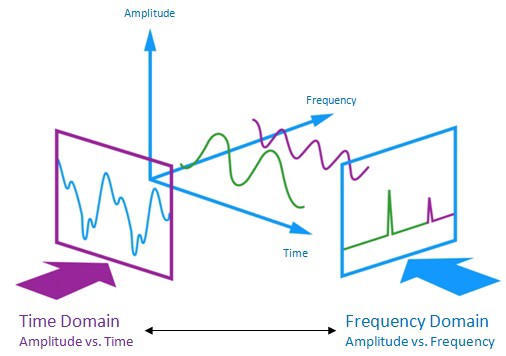
 <hr>
    <p>Image from https://towardsdatascience.com/extract-features-of-music-75a3f9bc265d </p>
</center>

In [ ]:
# Default FFT window size
n_fft = 2048 # FFT window size
hop_length = 512 # number audio of frames between STFT columns 

plt.figure(figsize=(30,30))
for i in range(1,10):
    plt.subplot(3,3,i)
    X = np.abs(librosa.stft(plot_audios[i][0], n_fft = n_fft, hop_length = hop_length))
    plt.plot(X)
    plt.xlabel("Frequency")
    plt.ylabel("Amplitude");
    try:
        plt.title("Fourier Transform of the sound of " + decoder[int(plot_files[i][-6:-4])] )
    except:
        plt.title("Fourier Transform of the sound of " + decoder[int(plot_files[i][-5:-4])] )

<div class="alert alert-block alert-info" style="font-size:14px; color:black; background-color:#ffeee6; border-color: #ff661a">
    <aside>
📙 
The Short-Time Fourier Transform (STFT) of audio from the ESC-50 dataset can be used to extract a wide range of information about the audio signal. Some of the information that can be extracted include:

- Spectrogram: The STFT produces a spectrogram, which is a time-frequency representation of the audio signal. This can be used to visualize the frequency content of the audio over time, and to identify patterns in the audio signal.

- Pitch detection: Pitch is the fundamental frequency of a sound, and can be estimated using the STFT. Pitch detection is important for understanding the musical notes in an audio file.

- Temporal information: The STFT provides a time-frequency representation of the audio, so it can be used to extract temporal information about the audio, such as the duration of a sound or the time between two sounds.

- Temporal-frequency information: STFT can be used to extract temporal-frequency information about the audio, such as the frequency of a sound at different time instants or the time of appearance of a frequency component.

- Sound characteristics: STFT can be used to extract characteristics of a sound, such as the spectral envelope or the harmonic structure.

## E. Spectrogram

A spectrogram is a time-frequency representation of a signal, such as an audio signal. It is a graphical representation of the frequency content of a signal over time, and is often used to visualize and analyze audio signals.

A spectrogram is typically represented as a 2D image, with the x-axis representing time, the y-axis representing frequency, and the intensity of the color or grayscale representing the amplitude of the frequency component at that point in time.

The spectrogram is calculated by applying the Short-Time Fourier Transform (STFT) to the audio signal, which breaks the audio into short segments and applies the Fourier transform to each segment. This produces a set of complex numbers representing the frequency content of the audio for each segment, which are then plotted in the spectrogram.

A spectrogram can be useful for visualizing the frequency content of a sound over time, and for identifying patterns in the audio signal, such as pitch, timbre, and transient events. It can also be used to analyze the characteristics of different sounds, such as the spectral envelope or the harmonic structure, and to segment an audio file into different sound events.

A spectrogram can be used in many audio-related tasks, such as speech recognition, audio source separation, and audio event detection, and it is an essential tool in the field of audio signal processing.

We can display a spectrogram using. librosa.display.specshow.

In [ ]:
plt.figure(figsize=(30,30))
for i in range(1,10):
    plt.subplot(3,3,i)
    X = librosa.stft(plot_audios[i][0])
    Xdb = librosa.amplitude_to_db(abs(X))
    librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')
    plt.colorbar()
    try:
        plt.title("Histogram of the sound of " + decoder[int(plot_files[i][-6:-4])] )
    except:
        plt.title("Histogram of the sound of " + decoder[int(plot_files[i][-5:-4])] )

<div class="alert alert-block alert-info" style="font-size:14px; color:black; background-color:#ffeee6; border-color: #ff661a">
    <aside>
📙 * The spectrogram shows the frequency content of the audio signal over time. This can be used to identify the fundamental frequency (pitch) of the sound, and to identify the different harmonics that make up the sound.

* The spectrogram provides a time-frequency representation of the audio, so it can be used to extract temporal information about the audio, such as the duration of a sound or the time between two sounds.

*  The spectrogram can be used to extract characteristics of a sound, such as the spectral envelope or the harmonic structure. This information can be used to identify the type of sound, such as a bird call or a car horn.

* The spectrogram can be used to segment an audio file into different sound events, which is useful for tasks such as audio event detection and audio scene analysis.

## F. Mel Spectrogram

### 1. The Mel Scale
Studies have shown that humans do not perceive frequencies on a linear scale. We are better at detecting differences in lower frequencies than higher frequencies. For example, we can easily tell the difference between 500 and 1000 Hz, but we will hardly be able to tell a difference between 10,000 and 10,500 Hz, even though the distance between the two pairs are the same.

In 1937, Stevens, Volkmann, and Newmann proposed a unit of pitch such that equal distances in pitch sounded equally distant to the listener. This is called the mel scale. We perform a mathematical operation on frequencies to convert them to the mel scale.

<center> 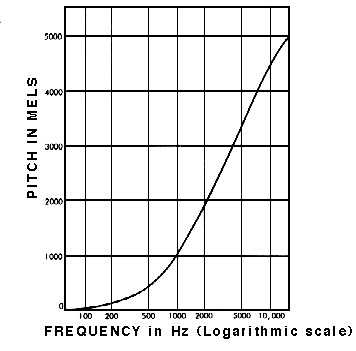 <br>Image from Simon Fraser University
 </center>


### 2. The Mel Spectrogram 

* A mel spectrogram is a spectrogram where the frequencies are converted to the mel scale. 

* A mel spectrogram logarithmically renders frequencies above a certain threshold (the corner frequency). For example, in the linearly scaled spectrogram, the vertical space between 1,000 and 2,000Hz is half of the vertical space between 2,000Hz and 4,000Hz. In the mel spectrogram, the space between those ranges is approximately the same. This scaling is analogous to human hearing, where we find it easier to distinguish between similar low frequency sounds than similar high frequency sounds.

* A mel spectrogram computes its output by multiplying frequency-domain values by a filter bank.

Source : https://developer.apple.com/documentation/accelerate/computing_the_mel_spectrum_using_linear_algebra

Source : 
https://medium.com/analytics-vidhya/understanding-the-mel-spectrogram-fca2afa2ce53

In [ ]:
plt.figure(figsize=(30,30))
for i in range(1,10):
    plt.subplot(3,3,i)
    X, _ = librosa.effects.trim(plot_audios[i][0])
    XS = librosa.feature.melspectrogram(X, sr=sr)
    Xdb = librosa.amplitude_to_db(XS, ref=np.max)
    librosa.display.specshow(Xdb, sr=plot_audios[i][1], x_axis='time', y_axis='hz')
    plt.colorbar()
    try:
        plt.title("Histogram of the sound of " + decoder[int(plot_files[i][-6:-4])] )
    except:
        plt.title("Histogram of the sound of " + decoder[int(plot_files[i][-5:-4])] )

## G. Feature extraction

### 1. Zero Crossing Rate

Zero-Crossing Rate: The zero-crossing rate (ZCR) is the rate at which a signal transitions from positive to zero to negative or negative to zero to positive. Its value has been extensively used in both speech recognition and music information retrieval for classifying percussive sounds.
<center>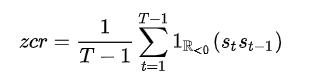</center>
The zero-crossing rate can be utilized as a basic pitch detection algorithm for monophonic tonal signals. Voice activity detection (VAD), which determines whether or not human speech is present in an audio segment, also makes use of zero-crossing rates.

source : https://www.analyticsvidhya.com/blog/2022/01/analysis-of-zero-crossing-rates-of-different-music-genre-tracks/

In [ ]:
plt.figure(figsize=(30,30))
for i in range(1,10):
    plt.subplot(3,3,i)
    zoom = 50
    y = plot_audios[i][0][0:zoom]
    librosa.display.waveshow(y)
    crossings = librosa.zero_crossings(y, pad=False)
    t = np.linspace(0, 0.0022, num=zoom)
    plt.scatter(t[crossings],y[crossings]*0, color='r',linewidth=7.0)
    try:
        plt.title("Sound of " + decoder[int(plot_files[i][-6:-4])] )
    except:
        plt.title("Sound of " + decoder[int(plot_files[i][-5:-4])] )

### 2. Harmonics and Perceptrual

Decompose an audio time series into harmonic and percussive components.

In [ ]:
plt.figure(figsize=(30,30))
for i in range(1,10):
    plt.subplot(3,3,i)
    y_harm, y_perc = librosa.effects.hpss(plot_audios[i][0])
    plt.plot(y_harm, alpha=0.4);
    plt.plot(y_perc, color = 'purple', alpha=0.8);
    try:
        plt.title("Sound of " + decoder[int(plot_files[i][-6:-4])] )
    except:
        plt.title("Sound of " + decoder[int(plot_files[i][-5:-4])] )

### 3. Tempo BMP (Beats Per Minute)

**What's a "beat?"**
People commonly use the word "beat" to mean "a pattern (or rhythm) played by drums." The thing you're making when you create and play patterns in these lessons is "a beat."

But, confusingly, there's another use of the word "beat," which means "a regular, repeating pulse that underlies a musical pattern." People tap their foot along with "the beat" in this context.

**Tempo**
The speed at which your patterns play back is called the tempo. Tempo is measured in beats per minute or BPM. So if we talk about a piece of music being "at 120 BPM," we mean that there are 120 beats (pulses) every minute.

Some types of musical patterns have a very clear underlying beat, while others have a more subtle or implied one.

Source :  https://learningmusic.ableton.com/make-beats/beat-and-tempo.html

In [ ]:
for i in range(1,10):
    tempo, _ = librosa.beat.beat_track(plot_audios[i][0], sr = plot_audios[i][1])
    try:
        print('File path : ', plot_files[i][len(data):])
        print('Sound of ' + decoder[int(plot_files[i][-6:-4])])
        print('BMP :',tempo )
        print('--------------------------')
    except:
        print('File path : ', plot_files[i][len(data):])
        print('Sound of ' + decoder[int(plot_files[i][-5:-4])])
        print('BMP :',tempo )
        print('--------------------------')

### 4. Spectral Centroid

The spectral centroid indicates at which frequency the energy of a spectrum is centered upon or in other words It indicates where the ” center of mass” for a sound is located. This is like a weighted mean:
<center>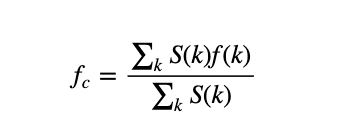</center>
where S(k) is the spectral magnitude at frequency bin k, f(k) is the frequency at bin k.

source : https://www.kdnuggets.com/2020/02/audio-data-analysis-deep-learning-python-part-1.html

In [ ]:
plt.figure(figsize=(30,30))
# Normalising the spectral centroid for visualisation
def normalize(x, axis=0):
    return sklearn.preprocessing.minmax_scale(x, axis=axis)

for i in range(1,10):
    plt.subplot(3,3,i)
    librosa.display.waveshow(plot_audios[i][0], alpha=0.4)
    spectral_centroids = librosa.feature.spectral_centroid(plot_audios[i][0], sr=plot_audios[i][1])[0]
    frames = range(len(spectral_centroids))
    t = librosa.frames_to_time(frames)
    plt.plot(t, normalize(spectral_centroids), color='r')
    try:
        plt.title("Sound of " + decoder[int(plot_files[i][-6:-4])] )
    except:
        plt.title("Sound of " + decoder[int(plot_files[i][-5:-4])] )

### 5. Spectral Rolloff

The spectral rolloff is a measure of the shape of the spectrum of an audio signal. It is defined as the frequency below which a certain percentage of the total energy of the signal lies. The roll-off point is often expressed as a percentage of the total energy, such as 85% or 95%.

The spectral rolloff can provide information about the tonality of a sound, as sounds that are more tonal will have a lower rolloff point than sounds that are more noise-like. For example, a piano playing a sustained note will have a lower rolloff point than a snare drum hit.

The spectral rolloff can be calculated by first computing the power spectrum of the audio signal, and then finding the frequency below which a certain percentage of the total energy of the signal lies. The spectral rolloff can be computed for different percentage values, and the result can be a single value, or a set of values for different percentages.

The spectral rolloff can be used in various audio-related tasks, such as music genre classification, sound event detection, and speech analysis, as it can be a useful feature to distinguish different audio classes. It can also be used in combination with other features, such as Mel-Frequency Cepstral Coefficients (MFCCs) or Chroma feature, to improve the performance of audio classification tasks.

In [ ]:
plt.figure(figsize=(30,30))
for i in range(1,10):
    plt.subplot(3,3,i)
    librosa.display.waveshow(plot_audios[i][0],alpha=0.4)
    spectral_rolloff = librosa.feature.spectral_rolloff(plot_audios[i][0]+0.01, sr=plot_audios[i][1])[0]
    frames = range(len(spectral_rolloff))
    t = librosa.frames_to_time(frames)
    plt.plot(t, normalize(spectral_rolloff), color='r')
    try:
        plt.title("Sound of " + decoder[int(plot_files[i][-6:-4])] )
    except:
        plt.title("Sound of " + decoder[int(plot_files[i][-5:-4])] )

### 6. Spectral Bandwidth

The spectral bandwidth is defined as the width of the band of light at one-half the peak maximum (or full width at half maximum [FWHM]) and is represented by the two vertical red lines and λSB on the wavelength axis.

<center> 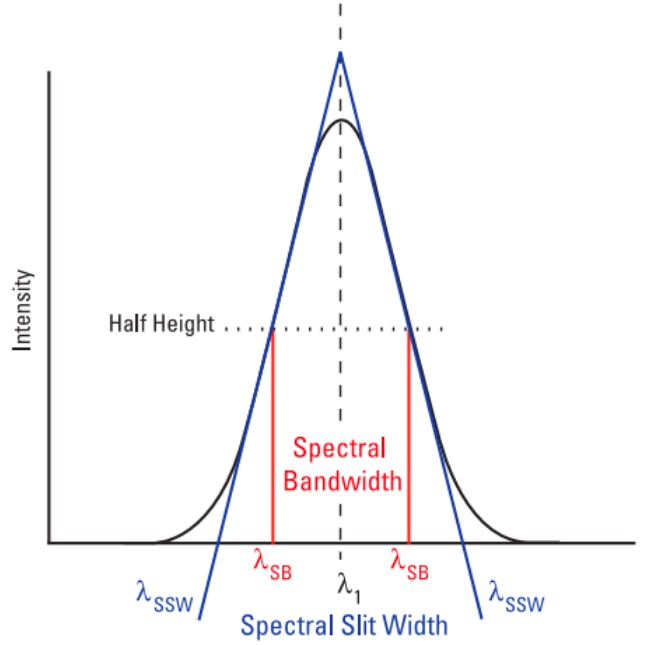 </center>

source : https://www.kdnuggets.com/2020/02/audio-data-analysis-deep-learning-python-part-1.html

In [ ]:
plt.figure(figsize=(30,30))
for i in range(1,10):
    plt.subplot(3,3,i)
    librosa.display.waveshow(plot_audios[i][0], alpha=0.4)
    spectral_bandwidth_2 = librosa.feature.spectral_bandwidth(plot_audios[i][0]+0.01, sr=plot_audios[i][1])[0]
    spectral_bandwidth_3 = librosa.feature.spectral_bandwidth(plot_audios[i][0]+0.01, sr=plot_audios[i][1], p=3)[0]
    spectral_bandwidth_4 = librosa.feature.spectral_bandwidth(plot_audios[i][0]+0.01, sr=plot_audios[i][1], p=4)[0]
    plt.plot(t, normalize(spectral_bandwidth_2), color='r')
    plt.plot(t, normalize(spectral_bandwidth_3), color='g')
    plt.plot(t, normalize(spectral_bandwidth_4), color='y')
    plt.legend(('p = 2', 'p = 3', 'p = 4'))
    try:
        plt.title("Sound of " + decoder[int(plot_files[i][-6:-4])] )
    except:
        plt.title("Sound of " + decoder[int(plot_files[i][-5:-4])] )


### 7. Chroma feature

Chroma feature is a representation of the harmonic structure of an audio signal. It is a powerful feature for music analysis and can be used for tasks such as music genre classification, chord recognition, and tonality analysis.

A Chroma feature is calculated by first transforming the audio signal into the frequency domain using a Fourier transform. The signal is then mapped into a new feature space called the Chroma space, which consists of 12 bins corresponding to the 12 distinct semitones of Western music.

Each bin represents the energy of the audio signal at a specific pitch class (C, C#, D, D#, etc.) and is calculated by summing the energy of all the notes in the signal that belong to that pitch class. The resulting Chroma feature is a 12-dimensional vector, where each dimension represents the energy of the audio signal at a specific pitch class.

The Chroma feature is robust to changes in tempo and instrumentation, which makes it a useful feature for tasks such as music genre classification and chord recognition. It can also be used in conjunction with other features, such as Mel-Frequency Cepstral Coefficients (MFCCs) or spectral rolloff, to improve the performance of audio classification tasks.

In [ ]:
plt.figure(figsize=(30,30))
for i in range(1,10):
    plt.subplot(3,3,i)
    chromagram = librosa.feature.chroma_stft(plot_audios[i][0], sr=plot_audios[i][1], hop_length=hop_length)
    librosa.display.specshow(chromagram, x_axis='time', y_axis='chroma', hop_length=hop_length, cmap='coolwarm')
    try:
        plt.title("Sound of " + decoder[int(plot_files[i][-6:-4])] )
    except:
        plt.title("Sound of " + decoder[int(plot_files[i][-5:-4])] )

### 8. Mel-Frequency Cepstral Coefficients(MFCCs)

Mel-Frequency Cepstral Coefficients (MFCCs) are a set of features commonly used in speech and music processing applications to represent the spectral characteristics of an audio signal. They are based on the human perception of sound and are designed to capture the spectral envelope of the audio signal, which is the shape of the signal's power spectrum over time.

The MFCCs are calculated in several steps:

- The audio signal is transformed into the frequency domain using a Fourier transform.
- The Mel scale is applied to the frequency axis of the signal, which approximates the non-linear frequency response of the human ear.
- The logarithm of the energy in each Mel-frequency bin is taken to obtain the Mel-frequency spectrogram.
- A Discrete Cosine Transform (DCT) is applied to the Mel-frequency spectrogram to obtain the MFCCs.

The result of these steps is a set of coefficients that represent the spectral envelope of the audio signal. The number of MFCCs used in a given application can vary, but typically, between 12 and 40 coefficients are used.

MFCCs are robust to variations in the audio signal, such as changes in pitch, speed, and noise. They are widely used in speech and music processing tasks such as speech recognition, music genre classification, and speaker identification. They can also be used in conjunction with other features, such as Chroma feature or Spectral rolloff, to improve the performance of audio classification tasks.

In [ ]:
plt.figure(figsize=(30,30))
for i in range(1,10):
    plt.subplot(3,3,i)
    mfccs = librosa.feature.mfcc(plot_audios[i][0], sr=plot_audios[i][1])
    librosa.display.specshow(mfccs, sr=plot_audios[i][1], x_axis='time')
    try:
        plt.title("Sound of " + decoder[int(plot_files[i][-6:-4])] )
    except:
        plt.title("Sound of " + decoder[int(plot_files[i][-5:-4])] )

# III. Data Preparation
---

## A. Data Augmentation

<div class="alert alert-block alert-info" style="font-size:14px; color:black; background-color:#e6ffe6; border-color: #1aff1a">
    <aside>
📗
Data augmentation is a technique used to artificially increase the size of a dataset by applying various transformations to the existing data. This can be useful in situations where the amount of available data is limited, such as with the ESC-50 dataset.

Data augmentation can be used to improve the robustness and generalization of machine learning models by introducing variation into the training data. This can help the model to learn more robust features that are less dependent on specific variations in the data.

There are several types of data augmentation that can be applied to the ESC-50 dataset:

- **Time stretching** : This technique changes the duration of the audio signal by speeding it up or slowing it down. This can be useful for simulating variations in the tempo of the audio.

- **Pitch shifting**: This technique changes the pitch of the audio signal by shifting it up or down. This can be useful for simulating variations in the pitch of the audio.

- **Volume scaling**: This technique changes the volume of the audio signal by scaling it up or down. This can be useful for simulating variations in the loudness of the audio.

- **Add noise** : This technique adds noise to the audio signal to simulate different noise conditions.

- **Time shifting**: This technique changes the position of the audio signal in time by shifting it forwards or backwards. This can be useful for simulating variations in the timing of the audio.

- **Echo**: This technique adds a delayed copy of the audio signal to simulate an echo effect

In [ ]:
path_audio = "/kaggle/input/environmental-sound-classification-50/audio/audio/16000/"

In [ ]:
def add_noise(data):
    noise = np.random.normal(0, 0.1, len(data))
    audio_noisy = data + noise
    return audio_noisy
    
def pitch_shifting(data):
    sr  = 16000
    bins_per_octave = 12
    pitch_pm = 2
    pitch_change =  pitch_pm * 2*(np.random.uniform())   
    data = librosa.effects.pitch_shift(data.astype('float64'),  sr, n_steps=pitch_change, 
                                          bins_per_octave=bins_per_octave)
    return pitch_shifting

def random_shift(data):
    timeshift_fac = 0.2 *2*(np.random.uniform()-0.5)  # up to 20% of length
    start = int(data.shape[0] * timeshift_fac)
    if (start > 0):
        data = np.pad(data,(start,0),mode='constant')[0:data.shape[0]]
    else:
        data = np.pad(data,(0,-start),mode='constant')[0:data.shape[0]]
    return data

def volume_scaling(data):
    sr  = 16000
    dyn_change = np.random.uniform(low=1.5,high=2.5)
    data = data * dyn_change
    return data
    
def time_stretching(data, rate=1.5):
    input_length = len(data)
    streching = data.copy()
    streching = librosa.effects.time_stretch(streching, rate)
    
    if len(streching) > input_length:
        streching = streching[:input_length]
    else:
        streching = np.pad(data, (0, max(0, input_length - len(streching))), "constant")
    return streching
def audio_augmentation(file, aug):
    directory = 'ESC-50-augmented-data/'
    if not os.path.exists(directory):
        os.makedirs(directory)
    aug = np.array(aug,dtype='float32').reshape(-1,1)
    sf.write(directory+'/'+ file, aug, 16000, 'PCM_24')

In [ ]:
def data_aug():
    path_ = np.random.choice(os.listdir(path_audio), size = (2000,), replace= False)
    for k,files in zip(range(len(path_)), path_):
        if files[0] != "5":
            data_, fs = librosa.load(os.path.join(path_audio, files), sr = 16000)
            noise_data = add_noise(data_)
    #         pitch_data = pitch_shifting(data_)
            random_shift_data = random_shift(data_)
            volume_scale_data = volume_scaling(data_)
            time_stretching_data =  time_stretching(data_, rate=1.5)
            aug = [noise_data,time_stretching_data, random_shift_data,volume_scale_data ]
            for j in range(len(aug)):
                filename = (files[0:2]+'generated'+'-'+str(j)+'-'+str(k)+'-'+files[2:])
                audio_augmentation(filename, aug[j])

## A. Feature Extraction  

There are several features that can be extracted from the audio files in the ESC-50 dataset, including:

- Mel-Frequency Cepstral Coefficients (MFCCs): These are a set of features that represent the spectral characteristics of an audio signal and are based on the human perception of sound.

- Spectral Rolloff: It is a measure of the shape of the spectrum of an audio signal that can provide information about the tonality of a sound.

- Chroma Feature: It is a representation of the harmonic structure of an audio signal and can be used for tasks such as music genre classification, chord recognition, and tonality analysis.

- Spectral Centroid: It is a measure of the center of gravity of the audio spectrum and can be used to estimate the brightness of a sound.


- Spectral Bandwidth: It is a measure of the width of the audio spectrum and can be used to estimate the sharpness of a sound.

- Zero Crossing Rate: It is a measure of the number of times the audio signal crosses the zero-level amplitude, and it can be used to estimate the presence of noise or harmonic content.

* https://librosa.org/doc/main/feature.html
* https://jonathanbgn.com/2021/08/30/audio-augmentation.html

In [ ]:
dataset['files_path'] = data+dataset['filename']
dataset  = dataset.drop(columns=['esc10','take','src_file','category'])
dataset.head()

In [ ]:
def update_dataframe():
    all_files = []
    data_aug = '/kaggle/working/ESC-50-augmented-data/'
    for path, subdirs, files in os.walk(data_aug):
        for name in files:
            fold = int(name[0])
            target = int(name.split('-')[-1].replace('.wav', ''))
            file_path = data_aug + name
            dataset.loc[-1] = [name, fold, target, file_path]
            dataset.index = dataset.index + 1  # shifting index
            dataset = dataset.sort_index()
            all_files.append(os.path.join(path, name))

In [ ]:
def create_esc_dataset():
    n_samples = dataset['filename'].shape[0]
    dataset['zero_crossing_rate'] = np.zeros(n_samples)
    dataset['chroma_stft'] = np.zeros(n_samples)
    dataset['rmse'] = np.zeros(n_samples)
    dataset['spectral_centroid'] = np.zeros(n_samples)
    dataset['spectral_bandwidth'] = np.zeros(n_samples)
    dataset['beat_per_minute'] = np.zeros(n_samples)
    dataset['rolloff'] = np.zeros(n_samples)
    for i in range(0, 20):
        dataset[f'mfcc_{i}'] = np.zeros((n_samples,))

    for i in tqdm(range(n_samples)):
        y , sr = librosa.load(dataset['files_path'][i], mono=True)
        dataset['rmse'][i] = np.mean(librosa.feature.rms(y=y))
        dataset['chroma_stft'][i] = np.mean(librosa.feature.chroma_stft(y=y, sr=sr))
        dataset['spectral_centroid'][i] = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
        dataset['spectral_bandwidth'][i] = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
        dataset['rolloff'][i] = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
        dataset['zero_crossing_rate'][i] = np.mean(librosa.feature.zero_crossing_rate(y))
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        dataset['beat_per_minute'] = tempo
        mfcc = librosa.feature.mfcc(y=y, sr=sr)
        for e in range(0, 20):
            dataset[f'mfcc_{e}'][i] = np.mean(mfcc[e])
dataset = pd.read_csv('/kaggle/input/esc-features-extracted/Esc50_features_extracted.csv')
dataset.head()

# IV. Modelling
___

## A. First Method : Using Machine Learning Models

### 1. Splitting the dataset into training set and validation set

Train Test Split : To have unknown datapoints to test the data rather than testing with the same points with which the model was trained. This helps capture the model performance much better.

<center> 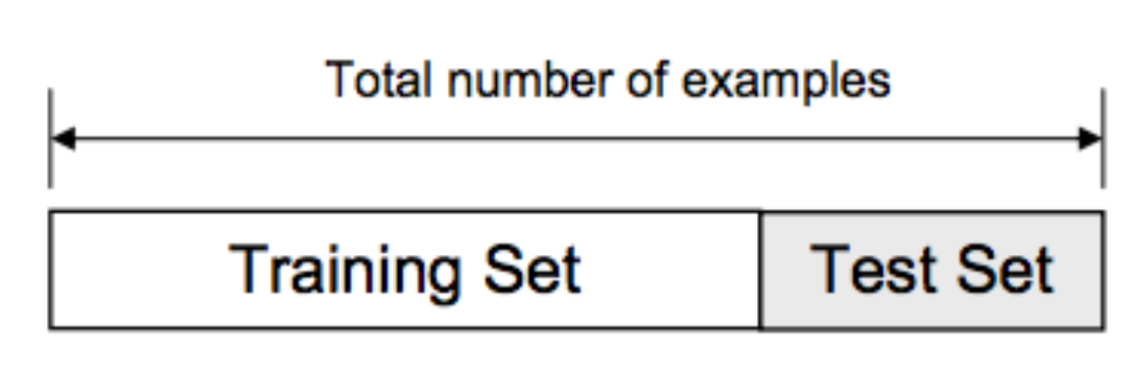</center>

About Stratify : Stratify parameter makes a split so that the proportion of values in the sample produced will be the same as the proportion of values provided to parameter stratify.

For example, if variable y is a binary categorical variable with values 0 and 1 and there are 25% of zeros and 75% of ones, stratify=y will make sure that your random split has 25% of 0's and 75% of 1's.

For Reference : https://towardsdatascience.com/train-test-split-and-cross-validation-in-python-80b61beca4b6

In [ ]:
train = dataset[dataset['fold'] < 5]
test = dataset[dataset['fold'] == 5]

X_train = train.drop(columns=['files_path','fold','filename','target' ,'src_file', 'take','category'])
y_train = train.target

X_test = test.drop(columns=['files_path','fold','filename','target' ,'src_file', 'take','category'])
y_test = test.target

print("Size of the training set : ", X_train.shape )
print("Size of the testing set : ", X_test.shape )

### 2. Feature scaling

In machine learning, feature scaling is a technique used to standardize the range of independent variables or features of data. Since the range of values of raw data varies widely, in some machine learning algorithms, objective functions will not work properly without normalization.

For example, the scale of an attribute like "age" ranges from 0 - 100, while the scale of "income" ranges from 0 - 100,000. In this case, the "age" variable will be on a different scale than the "income" variable and will be given a much lower weight.

One of the most common method to perform feature scaling is:

**Min-Max scaling (Normalization)**: This method scales the data between a given range, usually between 0 and 1. The new value of each feature x' is computed as $x' = \dfrac{(x - xmin)}{(xmax - xmin)}$

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0, 1))

dataset_transformed = scaler.fit_transform(X_train)
X_train = pd.DataFrame(dataset_transformed, columns=X_train.columns)

dataset_transformed = scaler.fit_transform(X_test)
X_test = pd.DataFrame(dataset_transformed, columns=X_test.columns)

### 3. Useful methods

In [ ]:
def plot_confusion_matrix(cm, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [ ]:
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5)):
    """Generate a simple plot of the test and training learning curve"""
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.grid()
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.legend(loc="best")
    return plt

In [ ]:
def plot_importance(df):
    """
    Builds the dataset to plot the feature importance.
    
    """
    # Sort features according to importance
    df = df.sort_values(['Importance'],ascending=False).reset_index()
    
    # drop the old index to avoid confusion
    df = df.drop(['index'],axis=1)
    
    # Make a horizontal bar chart of feature importances
    plt.figure(figsize = (10, 9))
    ax = plt.subplot()
    
    # Need to reverse the index to plot most important on top
    ax.barh(list(reversed(list(df.index[:30]))), 
            df['Importance'].head(30), 
            align = 'center', edgecolor = 'k')
    
    # Set the yticks and labels
    ax.set_yticks(list(reversed(list(df.index[:30]))))
    ax.set_yticklabels(df['Feature'].head(30))
    
    plt.xlabel("Normalized feature importance")
    plt.ylabel("Features")
    
    plt.show()
    return df

### 4. Modelling

In [ ]:
classifiers = [['SVC',SVC(kernel="rbf", C=0.025, probability=True, random_state=SEED)],
               ['ExtraTreesClassifier', ExtraTreesClassifier(random_state=SEED)],
              ["LinearDiscriminantAnalysis", LinearDiscriminantAnalysis()],
              ['DecisionTreeClassifier',DecisionTreeClassifier(random_state=SEED)],
              ['KNeighborsClassifier', KNeighborsClassifier()],
              ['RandomForestClassifier', RandomForestClassifier(random_state=SEED)],
              ['MLPClassifier',MLPClassifier(random_state=SEED)],
              ['AdaBoostClassifier',AdaBoostClassifier(random_state=SEED)],
              ['NuSVC',NuSVC(probability=True,random_state=SEED)],
              ['GaussianNB', GaussianNB()],
              ['QuadraticDiscriminantAnalysis',QuadraticDiscriminantAnalysis()]]

In [ ]:
from sklearnex import patch_sklearn, config_context
patch_sklearn()

def evaluate_classifiers(classifiers):
    models = []
    Accuracy_set = pd.DataFrame(index=None, columns=['Model','Accuracy(Train)','Accuracy(Test)','F1(Train)','F1(Test)', 'Precision(Train)','Precision(Test)', 'Recall(Train)','Recall(Test)', 'Log_loss(Train)','Log_loss(Test)'])
    for i in tqdm(range(len(classifiers))):
        name = classifiers[i][0]
        model = classifiers[i][1]

        model.fit(X_train,y_train)

        y_train_predicted = model.predict(X_train)
        y_test_predicited = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_predicted)
        accuracy_test = accuracy_score(y_test, y_test_predicited)

        f1_Score_train = f1_score(y_train, y_train_predicted,average='micro')
        f1_Score_test = f1_score(y_test, y_test_predicited,average='micro')

        precision_score_train = precision_score(y_train, y_train_predicted,average='micro')
        precision_score_test = precision_score(y_test, y_test_predicited,average='micro')

        recall_score_train = recall_score(y_train, y_train_predicted,average='micro')
        recall_score_test = recall_score(y_test, y_test_predicited,average='micro')

        log_loss_train = log_loss(y_train, model.predict_proba(X_train))
        log_loss_test = log_loss(y_test, model.predict_proba(X_test))

        # store the models
        models.append((name,accuracy_test,model))

        Accuracy_set = Accuracy_set.append(pd.Series({'Model':name, 'Accuracy(Train)':accuracy_train,'Accuracy(Test)':accuracy_test,'F1(Train)':f1_Score_train,'F1(Test)':f1_Score_test,'Precision(Train)':precision_score_train,'Precision(Test)':precision_score_test,'Recall(Train)':recall_score_train,'Recall(Test)':recall_score_test,'Log_loss(Train)':log_loss_train,'Log_loss(Test)':log_loss_test}),ignore_index=True )
    return Accuracy_set, models

In [ ]:
Accuracy_set, models = evaluate_classifiers(classifiers)
Accuracy_set.sort_values(by='Accuracy(Test)').style.background_gradient(cmap= plt.cm.Blues)

In [ ]:
plt.figure(figsize=(30,30))
g = sns.barplot(1,0, data = pd.DataFrame(models), palette="coolwarm",orient = "h")
g.set_xlabel("Mean Accuracy")
g = g.set_title("Cross validation scores")

### 5. Hyperparameter tunning for best models

I performed a grid search optimization for AdaBoost, ExtraTrees , RandomForest, GradientBoosting and SVC classifiers.

In [ ]:
RFC_Best_params_ = {'bootstrap': False, 'criterion': 'gini', 'max_depth': None, 'max_features': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
ExtC_best_params_ = {'bootstrap': False, 'criterion': 'gini', 'max_depth': None, 'max_features': 3, 'min_samples_leaf': 1, 'min_samples_split': 2,'n_estimators': 300}
NuSVC_best_params_ = {'gamma': 1, 'kernel': 'rbf', 'nu': 0.1}
MLPC_best_params_ =  {'activation':'tanh', 'early_stopping':True, 'hidden_layer_sizes':(500, 400, 300, 200, 100),'max_iter':300}

In [ ]:
classifiers = [['ExtraTreesClassifier', ExtraTreesClassifier(random_state=SEED, **ExtC_best_params_)],
              ['RandomForestClassifier', RandomForestClassifier(random_state=SEED, **RFC_Best_params_)],
              ['MLPClassifier', MLPClassifier(random_state=SEED, **MLPC_best_params_)],
              ['NuSVC',NuSVC(probability=True,random_state=SEED, **NuSVC_best_params_)],]

In [ ]:
Accuracy_set, models = evaluate_classifiers(classifiers)
Accuracy_set.sort_values(by='Accuracy(Test)').style.background_gradient(cmap= plt.cm.Blues)

In [ ]:
top_models = sorted(models, key=lambda tup: tup[1])

In [ ]:
plt.figure(figsize=(30,30))
for i in range(1,5):
    plt.subplot(2,2,i)
    cm = confusion_matrix(y_test, top_models[-i][2].predict(X_test))
    plot_confusion_matrix(cm,'Confusion matrix '+top_models[-i][0])

## B. Second Method :  Working on the Raw Audio

### 1. Data Loader

In [ ]:
class DataGenerator(Dataset):
    def __init__(self, path, transform = None, kind='train'):
        
        if kind=='train':
            files = Path(path).glob('[1-4]-*')
            self.items = [(str(file), file.name.split('-')[-1].replace('.wav', '')) for file in files]
#             files = Path('/kaggle/working/ESC-50-augmented-data').glob('[1-4]-*')
#             self.items += [(str(file), file.name.split('-')[-1].replace('.wav', '')) for file in files]
        if kind=='test':
            files = Path(path).glob('5-*')
            self.items = [(str(file), file.name.split('-')[-1].replace('.wav', '')) for file in files]
#             files = Path('/kaggle/working/ESC-50-augmented-data').glob('5-*')
#             self.items += [(str(file), file.name.split('-')[-1].replace('.wav', '')) for file in files]
            
        self.length = len(self.items)
        print(self.length)
    def __getitem__(self, index):
        filename, label = self.items[index]
        data_tensor, rate = torchaudio.load(filename)
        tmp = data_tensor[0,0:80000]
        return (tmp, int(label))
    
    def __len__(self):
        return self.length

### 2. Creating Train, Validation, Test sets

In [ ]:
batch_size = 64

train_data = DataGenerator(path_audio, kind='train')
test_data = DataGenerator(path_audio, kind='test')

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

### 3. Model 

This is a CNN (Convolutional Neural Network) architecture implemented using PyTorch's nn.Module class. The architecture is composed of several layers:

- The first layer is a 2D convolutional layer with 1 input channel, 16 output channels, kernel size of (1,8), stride of (1,1) and padding "same".
- The second layer is a batch normalization layer.
- The third layer is another 2D convolutional layer with 16 input channels and 16 output channels, kernel size of (1,8), stride of (1,1) and padding "same".
- The fourth layer is another batch normalization layer.
- The fifth layer is a max pooling layer with kernel size of (1,128), stride of (1,128) and no padding.
- The sixth layer is a 2D convolutional layer with 1 input channel, 32 output channels, kernel size of (3,3), stride of (1,1) and padding of 1.
- The seventh layer is a batch normalization layer.
- The eight layer is another 2D convolutional layer with 32 input channels and 32 output channels, kernel size of (3,3), stride of (1,1) and padding of 1.
- The nineth layer is another batch normalization layer.
- The tenth layer is a max pooling layer with kernel size of 4 and no padding.
- The eleventh layer is a 2D convolutional layer with 32 input channels, 64 output channels, kernel size of (3,3), stride of (2,2) and padding of 2.
- The twelfth layer is a batch normalization layer.
- The thirteenth layer is another 2D convolutional layer with 64 input channels and 64 output channels, kernel size of (3,3), stride of (2,2) and padding of 1.
- The fourteenth layer is another batch normalization layer.
- The fifteenth layer is a max pooling layer with kernel size of 2 and no padding.
- The sixteenth layer is a 2D convolutional layer with 64 input channels, 128 output channels, kernel size of (3,3), stride of (2,2) and padding of 1.
- The seventeenth layer is a batch normalization layer.
- The eighteenth layer is another 2D convolutional layer with 128 input channels and 128 output channels, kernel size of (3,3), stride of (2,2) and padding of 1.
- The nineteenth layer is another batch normalization layer.
- The twentieth layer is a max pooling layer with kernel size of (1,2) and no padding.
- The last layers are a fully connected linear layer with 256 input features and num_classes output features, and a dropout layer with a probability of 0.2.

<div class="alert alert-block alert-info" style="font-size:14px; color:black; background-color:#ffffcc; border-color: #e6e600">
    <aside>
📒
Each layer in the architecture is designed to extract relevant features from the input audio signal and pass them on to the next layer. The convolutional layers with different kernel sizes and strides are responsible for extracting features at different scales and locations in the signal. The max pooling layers reduce the spatial resolution of the feature maps and help to reduce the number of parameters in the network while also making it robust to small translations in the input signal.
        

The fully connected linear layer and the dropout layer at the end of the architecture are used to produce the final classification of the audio signal into one of the 50 classes.

In [ ]:
# Create a neural net class
class Net(nn.Module):
    
    
    # Defining the Constructor
    def __init__(self, num_classes=50):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=(1,8), stride=(1,1), padding="same")
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=16, kernel_size=(1,8), stride=(1,1), padding="same")
        self.bn2 = nn.BatchNorm2d(16)
        
        self.pool_1 = nn.MaxPool2d(kernel_size=(1,128), stride = (1,128), padding=0) 
        
        self.conv3 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(3,3), stride=(1,1), padding=1)
        self.bn3 = nn.BatchNorm2d(32)
        self.conv4 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(3,3), stride=(1,1), padding=1)
        self.bn4 = nn.BatchNorm2d(32)
        
        self.pool_2 = nn.MaxPool2d(kernel_size=4, padding=0) 
            
        self.conv5 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3,3), stride=(2,2), padding=2)
        self.bn5 = nn.BatchNorm2d(64)
        self.conv6 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(3,3), stride=(2,2), padding=1)
        self.bn6 = nn.BatchNorm2d(64)
        
        self.pool_3 = nn.MaxPool2d(kernel_size=2, padding=0) 
        
        self.conv7 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=(3,3), stride=(2,2), padding=1)
        self.bn7 = nn.BatchNorm2d(128)
        self.conv8 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=(3,3), stride=(2,2), padding=1)
        self.bn8 = nn.BatchNorm2d(128)
        
        self.pool_4 = nn.MaxPool2d(kernel_size=(1,2), padding=0) 
        
        self.dense = nn.Linear(in_features= 256, out_features=num_classes)
        # Define proportion or neurons to dropout
        self.dropout = nn.Dropout(0.2)
        
        

    def forward(self, x):
        x = x.unsqueeze(1).view(-1, 1, 1, 80000)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool_1(x)
        x = x.view((-1,1,16, 625))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.dropout(x)
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool_2(x)
        x = F.relu(self.bn5(self.conv5(x)))
        x = self.dropout(x)
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.pool_3(x)
        x = F.relu(self.bn7(self.conv7(x)))
        x = self.dropout(x)
        x = F.relu(self.bn8(self.conv8(x)))
        x = self.pool_4(x)
        x = x.view(x.size(0),-1)
        x = self.dense(x)
        x = self.dropout(x)
        return x
    
device = "cpu"
if (torch.cuda.is_available()):
    # if GPU available, use cuda (on a cpu, training will take a considerable length of time!)
    device = "cuda"

In [ ]:
model = Net(num_classes=50).to(device)
input_data = torch.randn(64, 1, 80000)
model_graph = draw_graph(model,input_data, roll=True)
model_graph.visual_graph

In [ ]:
# Create an instance of the model class and allocate it to the device
summary(model,(1,80000))

### 4. Training Loop

In [ ]:
def train(model, device, train_loader, optimizer, epoch):
    # Set the model to training mode
    model.train()
    train_loss = 0
    print("------------------------------- Epoch:", epoch,"-------------------------------")
    # Process the images in batches
    for batch_idx, (data, target) in enumerate(train_loader):
        # Use the CPU or GPU as appropriate
        # Recall that GPU is optimized for the operations we are dealing with
        data, target = data.to(device), target.to(device)

        # Reset the optimizer
        optimizer.zero_grad()

        # Push the data forward through the model layers
        output = model(data.to(device))

        # Get the loss
        loss = loss_criteria(output, target)

        # Keep a running total
        train_loss += loss.item()

        # Backpropagate
        loss.backward(retain_graph=True)
        optimizer.step()

        # Print metrics so we see some progress
        #print('\tTraining batch {} Loss: {:.6f}'.format(batch_idx + 1, loss.item()))
            
    # return average loss for the epoch
    avg_loss = train_loss / (batch_idx+1)
    print('Training set: Average loss: {:.6f}'.format(avg_loss))
    return avg_loss

### 5. Testing Loop

In [ ]:
def test(model, device, test_loader):
    # Switch the model to evaluation mode (so we don't backpropagate or drop)
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        batch_count = 0
        for data, target in test_loader:
            batch_count += 1
            data, target = data.to(device), target.to(device)
            
            # Get the predicted classes for this batch
            output = model(data)
            
            # Calculate the loss for this batch
            test_loss += loss_criteria(output, target).item()
            
            # Calculate the accuracy for this batch
            _, predicted = torch.max(output.data, 1)
            correct += torch.sum(target==predicted).item()

    # Calculate the average loss and total accuracy for this epoch
    avg_loss = test_loss / batch_count
    print('Validation set: Average loss: {:.6f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        avg_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))
    
    # return average loss for the epoch
    return avg_loss

### 6. Training & Evaluating the model

In [ ]:
def training(model):
    # Use an "Adam" optimizer to adjust weights
    optimizer = optim.Adam(model.parameters(), lr=3e-4)

    # Specify the loss criteria
    loss_criteria = nn.CrossEntropyLoss()

    # Track metrics in these arrays
    epoch_nums = []
    training_loss = []
    validation_loss = []

    # Train over 10 epochs (We restrict to 10 for time issues)
    epochs = 50
    print('Training on', device)
    for epoch in tqdm(range(1, epochs + 1)):
        train_loss = train(model, device, train_loader, optimizer, epoch)
        test_loss = test(model, device, test_loader)
        epoch_nums.append(epoch)
        training_loss.append(train_loss)
        validation_loss.append(test_loss)

In [ ]:
training(model)

## C. Third Method : Working on mel spectrogram

### 1. Utitity functions

In [ ]:
def visualize_log_mel_spect(mel_spectrogram_db,sample_rate,hop_length=320):
    librosa.display.specshow(mel_spectrogram_db, sr=sample_rate, x_axis='time', y_axis='mel',hop_length=hop_length)
    plt.colorbar(format='%+2.0f dB')
    plt.title('Log Mel spectrogram')
    plt.tight_layout()
    plt.show()

In [ ]:
def compute_log_mel_spect(audio,sample_rate):  # Size of the Fast Fourier Transform (FFT), which will also be used as the window length
    n_fft=1024
    hop_length=512
    window_type ='hann'
    mel_bins = 60 # Number of mel bands
    normalized_y = librosa.util.normalize(audio)
    Mel_spectrogram = librosa.feature.melspectrogram(y=normalized_y, sr=22050,hop_length=hop_length, win_length=n_fft, n_mels = mel_bins)
    mel_spectrogram_db = librosa.power_to_db(Mel_spectrogram)
    return  mel_spectrogram_db

### 2. Preparing the training data

In [ ]:
data=[]

for i in tqdm(range(len(dataset))):
    wave_file=dataset.iat[i,8]
#     wave_file=dataset.iat[i,3]
    audio, sample_rate = librosa.load(wave_file)
    mel_spectrogram_db=(compute_log_mel_spect(audio,sample_rate))
    delta=librosa.feature.delta(mel_spectrogram_db)
    data.append( np.dstack( (mel_spectrogram_db,delta) ))

dataset['data']=data

In [ ]:
from torchvision.transforms import Resize

import torchaudio.transforms as T

train_df = dataset[dataset['fold'] < 5]
test_df = dataset[dataset['fold'] == 5]

train_df = train_df[['data','target']]
test_df = test_df[['data','target']]

### 3. Data Loader

In [ ]:
class escDataset(Dataset):
    def __init__(self,dataset, transformation, device):
        self.dataset = dataset
        self.device = device
        self.transformation = transformation
        self.length=len(self.dataset)

    def __len__(self):
        return self.length
    
    def __getitem__(self, index):
        spectogram = torch.tensor(self._get_audio_spectogram(index))
        label = self._get_audio_sample_label(index)
        spectogram=spectogram.permute(2, 0, 1)
        resize_transform = Resize((60, 216))
        spectogram = resize_transform(spectogram)
        #spectogram  = spectogram.to(self.device)
        #spectogram  = self.transformation(spectogram)
        return spectogram, label
    def _get_audio_spectogram(self, index):
        y = self.dataset.iloc[index, 0].astype(np.float32)
        return y

    def _get_audio_sample_label(self, index):
        return self.dataset.iloc[index, 1]

In [ ]:
class MyReshape(object):
    """Reshape the image array."""
    
    def __init__(self, output_size):
        assert isinstance(output_size, (tuple))

        self.output_size = output_size
    def __call__(self, image):
        return image.reshape(self.output_size)

In [ ]:
# build transformation pipelines for data augmentation

train_transforms = transforms.Compose([ MyReshape(output_size=(2,60, 216) ) ])
test_transforms = transforms.Compose([MyReshape(output_size=(2,60, 216))])

In [ ]:
batch_size = 50
device='cuda'

train_data = escDataset(train_df,train_transforms,device)
test_data = escDataset(test_df,train_transforms,device)

train_loader = DataLoader(train_data, batch_size=batch_size,shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

# 4. Model

This is a CNN architecture implemented using PyTorch's nn.Module class. This architecture is composed of several layers:

- The first layer is a 2D convolutional layer with 2 input channels, 24 output channels, kernel size of (6,6), stride of 1 and relu activation function.
- The second layer is a batch normalization layer.
- The third layer is another 2D convolutional layer with 24 input channels, 24 output channels, kernel size of (6,6), stride of 1 and LeakyReLU activation function.
- The fourth layer is another batch normalization layer.
- The fifth layer is another 2D convolutional layer with 24 input channels, 48 output channels, kernel size of (5,5), stride of (2,2) and LeakyReLU activation function.
- The sixth layer is another batch normalization layer.
- The seventh layer is another 2D convolutional layer with 48 input channels, 48 output channels, kernel size of (5,5), stride of (2,2) and LeakyReLU activation function.
- The eight layer is another batch normalization layer.
- The nineth layer is another 2D convolutional layer with 48 input channels, 64 output channels, kernel size of (4,4), stride of 1 and LeakyReLU activation function.
- The tenth layer is another batch normalization layer.
- The eleventh layer is another 2D convolutional layer with 64 input channels, 64 output channels, kernel size of (4,4), stride of 1 and LeakyReLU activation function.
- The twelfth layer is another batch normalization layer.
- The last layers are a flatten layer, a fully connected linear layer with 64443 input features and 200 output features, a dropout layer with a probability of 0.25, another fully connected linear layer with 200 input features and 50 output features, and a softmax layer.

<div class="alert alert-block alert-info" style="font-size:14px; color:black; background-color:#ffffcc; border-color: #e6e600">
    <aside>
📒 This CNN architecture is designed for classifying mel-spectograms of the ESC-50 dataset. 

The architecture starts with a 2D convolutional layer which takes 2 channel mel-spectograms as input and applies multiple filters with a kernel size of (6,6) and stride of 1, this layer is responsible for detecting features in the input data, then the feature maps are passed through a relu activation function which adds non-linearity to the model, then the feature maps are passed through a batch normalization layer which normalizes the data, this process is done multiple times with different kernels and strides.

The last layers are fully connected layers that are responsible for the final classification of the audio signal into one of the 50 classes. The softmax function is used to output a probability for each class.

In [ ]:
class CNN(nn.Module):

    def __init__(self):
        super().__init__()
        # 5 conv blocks / flatten / linear / softmax
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=2, out_channels=24,kernel_size=(6,6),stride=1),
            nn.ReLU(),
            nn.BatchNorm2d(24)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=24,out_channels=24,kernel_size=(6,6),stride=1),
            nn.LeakyReLU(0.2),
            nn.BatchNorm2d(24)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=24,out_channels=48,kernel_size=(5,5),stride=(2,2)),
            nn.LeakyReLU(0.2),
            nn.BatchNorm2d(48)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=48,out_channels=48,kernel_size=(5,5),stride=(2,2)),
            nn.LeakyReLU(0.2),
            nn.BatchNorm2d(48)
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(in_channels=48,out_channels=64,kernel_size=(4,4),stride=1),
            nn.LeakyReLU(0.2),
            nn.BatchNorm2d(64)
        )
        self.conv6 = nn.Sequential(
            nn.Conv2d(in_channels=64,out_channels=64,kernel_size=(4,4),stride=1),
            nn.LeakyReLU(0.2),
            nn.BatchNorm2d(64)
        )
        self.connected_layer=nn.Sequential(
          nn.Flatten(),
          nn.Linear(64*4*43, 200),
          nn.Dropout(0.25),
          nn.Linear(200, 50), #200 unit
          nn.Softmax()
        )

    def forward(self, input_data):
        input_data = input_data.to('cuda')
        x = self.conv1(input_data)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = self.conv6(x)
        x= self.connected_layer(x)
        return x

In [ ]:
cnn = CNN().cuda()
input_data = torch.randn(64, 2,60,216)
model_graph = draw_graph(cnn,input_data, roll=True)
model_graph.visual_graph

In [ ]:
summary(cnn,(2,60,216))

# 5. Training the model 

In [ ]:
training(CNN().cuda())

<hr>

<center><h1>V. Evaluation</h1></center>

<hr>


<div class="alert alert-block alert-info" style="font-size:14px; color:black; background-color:#e6f2ff; border-color: #3399ff">
    <aside>
    📘 In conclusion, using different machine learning algorithms and CNN architectures on the ESC-50 dataset can lead to varying levels of performance. 

For example, traditional machine learning algorithms such as Random Forest and Support Vector Machine have been shown to perform well on this dataset, achieving high accuracy scores. However, more recent and complex models such as Convolutional Neural Networks (CNNs) have also been shown to be effective on this dataset, especially when using architectures specifically designed for audio classification.

It's also worth noting that the ESC-50 dataset is a small dataset, when training deep learning models, it is important to use techniques such as data augmentation to improve the generalization of the model.

In summary, We tried different machine learning algorithms and CNN architectures when working with the ESC-50 dataset and carefully evaluate their performance to find the best solution for the problem at hand.